In [15]:
import os
import json
import csv
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [5]:
BASE_DIR = Path(".")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "EMNIST"

In [6]:
transform = transforms.ToTensor()

root = str((BASE_DIR / "data").resolve())

if DATASET_NAME == "KMNIST":
    full_train_dataset = datasets.KMNIST(
        root=root,
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.KMNIST(
        root=root,
        train=False,
        download=True,
        transform=transform,
    )
elif DATASET_NAME == "EMNIST":
    full_train_dataset = datasets.EMNIST(
        root=root,
        split="balanced",
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.EMNIST(
        root=root,
        split="balanced",
        train=False,
        download=True,
        transform=transform,
    )
elif DATASET_NAME == "CIFAR10":
    full_train_dataset = datasets.CIFAR10(
        root=root,
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.CIFAR10(
        root=root,
        train=False,
        download=True,
        transform=transform,
    )
else:
    raise ValueError(f"Unknown DATASET_NAME: {DATASET_NAME}")

num_train_full = len(full_train_dataset)
val_ratio = 0.2
num_val = int(num_train_full * val_ratio)
num_train = num_train_full - num_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [num_train, num_val],
    generator=torch.Generator().manual_seed(SEED),
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

x0, y0 = full_train_dataset[0]
input_size = int(np.prod(x0.shape))
num_classes = len(full_train_dataset.classes) if hasattr(full_train_dataset, "classes") else int(max(full_train_dataset.targets)) + 1

len(full_train_dataset), len(train_dataset), len(val_dataset), len(test_dataset), input_size, num_classes

(112800, 90240, 22560, 18800, 784, 47)

Batch shapes:
images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])
Value range in images:  0.0 1.0


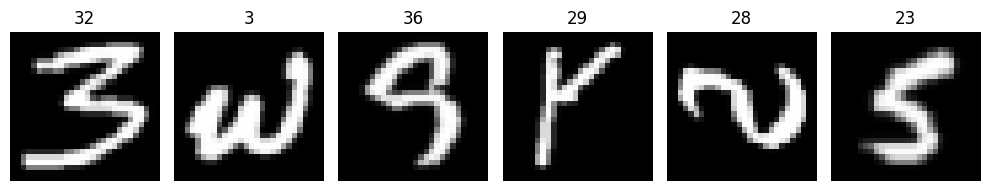

In [7]:
batch = next(iter(train_loader))
images, labels = batch

print("Batch shapes:")
print("images:", images.shape)
print("labels:", labels.shape)
print("Value range in images: ", float(images.min()), float(images.max()))

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i, 0].numpy(), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_sizes,
        num_classes: int,
        activation: str = "relu",
        use_dropout: bool = False,
        dropout_p: float = 0.3,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        layers = []
        in_features = input_size

        if activation == "relu":
            act_layer = nn.ReLU
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        for hidden in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(act_layer())
            if use_dropout:
                layers.append(nn.Dropout(p=dropout_p))
            in_features = hidden

        layers.append(nn.Linear(in_features, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


print("Example MLP summary:")
example_model = MLP(
    input_size=input_size,
    hidden_sizes=[512, 256, 128],
    num_classes=num_classes,
    activation="relu",
    use_dropout=False,
    use_batchnorm=False,
)
print(example_model)

Example MLP summary:
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=47, bias=True)
  )
)


In [9]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).float().sum().item()
    return correct / targets.size(0)


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        batch_size_cur = targets.size(0)
        running_loss += loss.item() * batch_size_cur
        running_correct += (outputs.argmax(dim=1) == targets).float().sum().item()
        total += batch_size_cur

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            batch_size_cur = targets.size(0)
            running_loss += loss.item() * batch_size_cur
            running_correct += (outputs.argmax(dim=1) == targets).float().sum().item()
            total += batch_size_cur

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs: int,
    use_early_stopping: bool = False,
    patience: int = 5,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_state = deepcopy(model.state_dict())
    best_val_acc = -np.inf
    best_val_loss = np.inf
    epochs_trained = 0
    epochs_since_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        epochs_trained += 1

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        if use_early_stopping and epochs_since_improvement >= patience:
            print(f"Early stopping triggered (patience={patience}) at epoch {epoch}.")
            break

    # Load best weights
    model.load_state_dict(best_state)

    history["epochs_trained"] = epochs_trained
    history["best_val_accuracy"] = best_val_acc
    history["best_val_loss"] = best_val_loss

    return history

In [10]:
RUNS = []
HISTORIES = {}


def build_model(model_config):
    model = MLP(
        input_size=input_size,
        hidden_sizes=model_config["hidden_sizes"],
        num_classes=num_classes,
        activation=model_config.get("activation", "relu"),
        use_dropout=model_config.get("use_dropout", False),
        dropout_p=model_config.get("dropout_p", 0.3),
        use_batchnorm=model_config.get("use_batchnorm", False),
    )
    return model.to(device)


def get_optimizer(model, optim_name, lr, weight_decay=0.0, momentum=0.0):
    if optim_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optim_name == "SGD":
        return optim.SGD(
            model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optim_name}")


def summarize_model_config(model_config):
    hidden_str = "-".join(str(h) for h in model_config["hidden_sizes"])
    parts = [
        f"MLP[{input_size}-{hidden_str}-{num_classes}]",
        f"act={model_config.get('activation', 'relu')}",
        f"dropout={model_config.get('dropout_p', 0.0) if model_config.get('use_dropout', False) else 0.0}",
        f"batchnorm={model_config.get('use_batchnorm', False)}",
    ]
    return ", ".join(parts)


def run_experiment(
    experiment_id: str,
    model_config: dict,
    optim_config: dict,
    train_config: dict,
    use_early_stopping: bool = False,
    early_stopping_patience: int = 5,
):
    print(f"===== Running experiment {experiment_id} =====")

    model = build_model(model_config)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(
        model,
        optim_name=optim_config["optimizer"],
        lr=optim_config["lr"],
        weight_decay=optim_config.get("weight_decay", 0.0),
        momentum=optim_config.get("momentum", 0.0),
    )

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=train_config["epochs"],
        use_early_stopping=use_early_stopping,
        patience=early_stopping_patience,
    )

    HISTORIES[experiment_id] = history

    run_row = {
        "experiment_id": experiment_id,
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": summarize_model_config(model_config),
        "optimizer": optim_config["optimizer"],
        "lr": optim_config["lr"],
        "momentum": optim_config.get("momentum", 0.0),
        "weight_decay": optim_config.get("weight_decay", 0.0),
        "epochs_trained": history["epochs_trained"],
        "best_val_accuracy": history["best_val_accuracy"],
        "best_val_loss": history["best_val_loss"],
    }

    RUNS.append(run_row)

    return model, history

In [11]:
base_model_config = {
    "hidden_sizes": [512, 256, 128],
    "activation": "relu",
    "use_dropout": False,
    "dropout_p": 0.0,
    "use_batchnorm": False,
}

adam_base_config = {
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
}

train_config_base = {"epochs": 10}

model_E1, history_E1 = run_experiment(
    experiment_id="E1",
    model_config=base_model_config,
    optim_config=adam_base_config,
    train_config=train_config_base,
    use_early_stopping=False,
)

# E2: add Dropout
model_config_E2 = base_model_config.copy()
model_config_E2.update({"use_dropout": True, "dropout_p": 0.3})
model_E2, history_E2 = run_experiment(
    experiment_id="E2",
    model_config=model_config_E2,
    optim_config=adam_base_config,
    train_config=train_config_base,
    use_early_stopping=False,
)

model_config_E3 = base_model_config.copy()
model_config_E3.update({"use_batchnorm": True})
model_E3, history_E3 = run_experiment(
    experiment_id="E3",
    model_config=model_config_E3,
    optim_config=adam_base_config,
    train_config=train_config_base,
    use_early_stopping=False,
)

# Choose best of E2/E3 by val_accuracy for EarlyStopping experiment E4
val_acc_E2 = HISTORIES["E2"]["best_val_accuracy"]
val_acc_E3 = HISTORIES["E3"]["best_val_accuracy"]

if val_acc_E2 >= val_acc_E3:
    best_model_config_for_E4 = model_config_E2
else:
    best_model_config_for_E4 = model_config_E3

train_config_E4 = {"epochs": 20}

model_E4, history_E4 = run_experiment(
    experiment_id="E4",
    model_config=best_model_config_for_E4,
    optim_config=adam_base_config,
    train_config=train_config_E4,
    use_early_stopping=True,
    early_stopping_patience=5,
)

best_model = model_E4
best_history = history_E4
best_model_config = best_model_config_for_E4
best_optim_config = adam_base_config
best_train_config = train_config_E4

print("Best regularized model config for E4:")
print("model_config:", best_model_config)
print("optim_config:", best_optim_config)
print("train_config:", best_train_config)
print("Best val accuracy (E4):", best_history["best_val_accuracy"])

===== Running experiment E1 =====
Epoch 1/10 | train_loss=1.1475, train_acc=0.6619, val_loss=0.7049, val_acc=0.7718
Epoch 2/10 | train_loss=0.6009, train_acc=0.8026, val_loss=0.5612, val_acc=0.8155
Epoch 3/10 | train_loss=0.4956, train_acc=0.8300, val_loss=0.5194, val_acc=0.8292
Epoch 4/10 | train_loss=0.4338, train_acc=0.8491, val_loss=0.4839, val_acc=0.8369
Epoch 5/10 | train_loss=0.3883, train_acc=0.8608, val_loss=0.4804, val_acc=0.8406
Epoch 6/10 | train_loss=0.3527, train_acc=0.8711, val_loss=0.4713, val_acc=0.8440
Epoch 7/10 | train_loss=0.3254, train_acc=0.8784, val_loss=0.4591, val_acc=0.8484
Epoch 8/10 | train_loss=0.3001, train_acc=0.8860, val_loss=0.4903, val_acc=0.8369
Epoch 9/10 | train_loss=0.2816, train_acc=0.8914, val_loss=0.4784, val_acc=0.8464
Epoch 10/10 | train_loss=0.2618, train_acc=0.8977, val_loss=0.4842, val_acc=0.8481
===== Running experiment E2 =====
Epoch 1/10 | train_loss=1.4874, train_acc=0.5636, val_loss=0.7550, val_acc=0.7613
Epoch 2/10 | train_loss=0.840

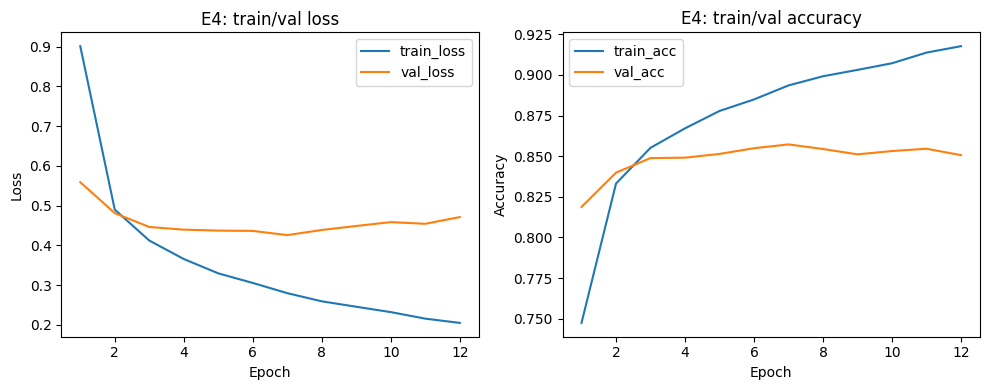

Saved: artifacts\figures\curves_best.png
Test loss: 0.4493, test accuracy: 0.8512


In [12]:
epochs_E4 = range(1, best_history["epochs_trained"] + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_E4, best_history["train_loss"][: best_history["epochs_trained"]], label="train_loss")
plt.plot(epochs_E4, best_history["val_loss"][: best_history["epochs_trained"]], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E4: train/val loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_E4, best_history["train_acc"][: best_history["epochs_trained"]], label="train_acc")
plt.plot(epochs_E4, best_history["val_acc"][: best_history["epochs_trained"]], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E4: train/val accuracy")
plt.legend()

plt.tight_layout()
fig_path_best = FIGURES_DIR / "curves_best.png"
plt.savefig(fig_path_best)
plt.show()

print("Saved:", fig_path_best)

criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

best_test_metrics = {"test_loss": float(test_loss), "test_accuracy": float(test_acc)}

===== Running experiment O1 =====
Epoch 1/6 | train_loss=1.0763, train_acc=0.6724, val_loss=0.7839, val_acc=0.7549
Epoch 2/6 | train_loss=0.7361, train_acc=0.7625, val_loss=0.6325, val_acc=0.7935
Epoch 3/6 | train_loss=0.6492, train_acc=0.7870, val_loss=0.6633, val_acc=0.7887
Epoch 4/6 | train_loss=0.5995, train_acc=0.8014, val_loss=0.5864, val_acc=0.8091
Epoch 5/6 | train_loss=0.5716, train_acc=0.8085, val_loss=0.5699, val_acc=0.8179
Epoch 6/6 | train_loss=0.5436, train_acc=0.8164, val_loss=0.5840, val_acc=0.8053
===== Running experiment O2 =====
Epoch 1/6 | train_loss=3.3507, train_acc=0.2494, val_loss=2.9303, val_acc=0.4304
Epoch 2/6 | train_loss=2.6966, train_acc=0.4976, val_loss=2.4905, val_acc=0.5438
Epoch 3/6 | train_loss=2.3281, train_acc=0.5795, val_loss=2.1704, val_acc=0.6076
Epoch 4/6 | train_loss=2.0525, train_acc=0.6300, val_loss=1.9294, val_acc=0.6498
Epoch 5/6 | train_loss=1.8268, train_acc=0.6672, val_loss=1.7217, val_acc=0.6812
Epoch 6/6 | train_loss=1.6371, train_acc=

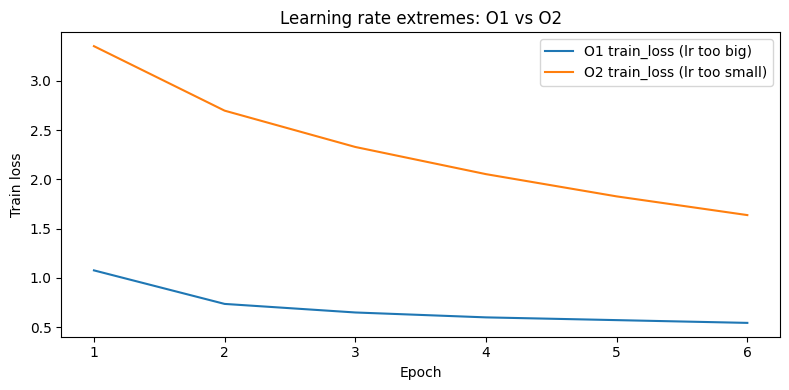

Saved: artifacts\figures\curves_lr_extremes.png


In [13]:
adam_large_lr_config = {
    "optimizer": "Adam",
    "lr": 1e-1,
    "weight_decay": 0.0,
}

adam_small_lr_config = {
    "optimizer": "Adam",
    "lr": 1e-5,
    "weight_decay": 0.0,
}

sgd_config = {
    "optimizer": "SGD",
    "lr": 1e-2,
    "momentum": 0.9,
    "weight_decay": 1e-4,
}

train_config_short = {"epochs": 6}
train_config_sgd = {"epochs": 10}

model_O1, history_O1 = run_experiment(
    experiment_id="O1",
    model_config=best_model_config,
    optim_config=adam_large_lr_config,
    train_config=train_config_short,
    use_early_stopping=False,
)

model_O2, history_O2 = run_experiment(
    experiment_id="O2",
    model_config=best_model_config,
    optim_config=adam_small_lr_config,
    train_config=train_config_short,
    use_early_stopping=False,
)

model_O3, history_O3 = run_experiment(
    experiment_id="O3",
    model_config=best_model_config,
    optim_config=sgd_config,
    train_config=train_config_sgd,
    use_early_stopping=False,
)

plt.figure(figsize=(8, 4))

epochs_O1 = range(1, history_O1["epochs_trained"] + 1)
plt.plot(epochs_O1, history_O1["train_loss"][: history_O1["epochs_trained"]], label="O1 train_loss (lr too big)")

epochs_O2 = range(1, history_O2["epochs_trained"] + 1)
plt.plot(epochs_O2, history_O2["train_loss"][: history_O2["epochs_trained"]], label="O2 train_loss (lr too small)")

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Learning rate extremes: O1 vs O2")
plt.legend()

fig_path_lr = FIGURES_DIR / "curves_lr_extremes.png"
plt.tight_layout()
plt.savefig(fig_path_lr)
plt.show()

print("Saved:", fig_path_lr)

In [14]:
best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(best_model.state_dict(), best_model_path)
print("Saved best model to", best_model_path)

best_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_config": best_model_config,
    "optim_config": best_optim_config,
    "train_config": best_train_config,
    "best_val_accuracy": float(best_history["best_val_accuracy"]),
    "best_val_loss": float(best_history["best_val_loss"]),
    "test_metrics": best_test_metrics,
}

best_config_path = ARTIFACTS_DIR / "best_config.json"
with best_config_path.open("w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)
print("Saved best config to", best_config_path)

# Save runs.csv
runs_csv_path = ARTIFACTS_DIR / "runs.csv"
fieldnames = [
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "momentum",
    "weight_decay",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss",
]

with runs_csv_path.open("w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for row in RUNS:
        writer.writerow(row)

print("Saved runs to", runs_csv_path)

runs_csv_path, best_model_path, best_config_path

Saved best model to artifacts\best_model.pt
Saved best config to artifacts\best_config.json
Saved runs to artifacts\runs.csv


(WindowsPath('artifacts/runs.csv'),
 WindowsPath('artifacts/best_model.pt'),
 WindowsPath('artifacts/best_config.json'))